# 05 - Preparación de variables y selección temporal

En esta etapa evaluamos si una representación más informativa de las transacciones mejora el modelo de referencia. Después comparamos configuraciones de XGBoost dentro del bloque train. No utilizamos la validación externa ni test para elegir variables o hiperparámetros.

La comparación tiene dos propósitos distintos: contrastar atributos base e históricos con parámetros iguales y explorar dos configuraciones adicionales sobre los atributos ampliados. La búsqueda es acotada y predeclarada; sus resultados no demuestran un óptimo global.

El modelo seleccionado deberá reajustarse con todo train y recibir un calibrador nuevo. Esta etapa no reemplaza los artefactos de la línea base ni recalcula ahorros.


## 1. Fijar el diseño antes de observar resultados

Usamos dos ventanas expansivas dentro de train. Sus cortes se sitúan al 60% y 80% de su duración, con siete días excluidos antes de cada evaluación. Seleccionamos por AP media de ambos folds; Brier y log-loss son diagnósticos de probabilidades todavía sin calibración.

No aplicamos remuestreo ni early stopping sobre estas ventanas. Todas las configuraciones usan 250 árboles y cuatro hilos. La grilla y las ventanas quedan registradas con las fuentes para que podamos reproducir la decisión.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from fraud_cost.selection import (
    load_train_only, temporal_folds, fold_summary,
    run_temporal_search, save_selection, DEFAULT_CANDIDATES,
)
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir() and (p / "data").is_dir())
TRAIN_END_FRACTIONS = (0.60, 0.80)
GAP_DAYS = 7
CANDIDATES = DEFAULT_CANDIDATES
display(CANDIDATES)


({'candidate': 'reference', 'features': 'base', 'params': {}},
 {'candidate': 'history', 'features': 'history', 'params': {}},
 {'candidate': 'history_regularized',
  'features': 'history',
  'params': {'max_depth': 4, 'min_child_weight': 20, 'reg_lambda': 5}},
 {'candidate': 'history_deeper',
  'features': 'history',
  'params': {'max_depth': 8, 'min_child_weight': 10, 'reg_lambda': 5}})

## 2. Recuperar únicamente train y comprobar las ventanas

Filtramos las transacciones con el manifiesto antes de unir identidad. La búsqueda recibe exclusivamente train; las etiquetas de los bloques posteriores no se agregan ni se puntúan.

Las fracciones se calculan sobre tiempo, no cantidad de filas. Verificamos el orden estricto, la separación y la presencia de ambas clases en cada ventana. Un periodo tardío puede convertirse en entrenamiento en el siguiente fold: es el comportamiento de una ventana expansiva.


In [2]:
train = load_train_only(ROOT)
folds = temporal_folds(train, train_end_fractions=TRAIN_END_FRACTIONS, gap_days=GAP_DAYS)
windows = fold_summary(train, folds)
display(windows)
print(f"Entrada de esta etapa: {len(train):,} transacciones, todas del bloque train.")


,fold,train_rows,eval_rows,train_frauds,eval_frauds,train_end,eval_start,eval_end,gap_days
0,1,242198,44024,7879,1677,5747276,6352100,7634011,7
1,2,307224,46113,10406,1703,7634011,8239468,9521218,7


Entrada de esta etapa: 380,815 transacciones, todas del bloque train.


## 3. Variables y garantías contra fuga de información

El esquema base mantiene las variables originales utilizables y has_identity. El ampliado añade log1p del monto, cantidad de faltantes, fases cíclicas relativas diaria/semanal y tres atributos históricos por agrupación: número de operaciones anteriores, monto promedio anterior y segundos desde la última.

Agrupamos por una clave compuesta de tarjeta, DeviceInfo y dominio de correo. Son proxies operativos: una combinación no identifica de forma verificada una tarjeta o persona, DeviceInfo no identifica necesariamente un dispositivo físico y un dominio agrupa muchos usuarios.

En entrenamiento, cada historial excluye la operación actual y todas las de su mismo instante. En evaluación, usamos el estado congelado de entrenamiento: no incorporamos operaciones del gap ni de la ventana evaluada. Las entidades nuevas o con claves incompletas reciben conteo cero e historial numérico ausente. No usamos tasas de fraude por entidad.

Medianas, indicadores de ausencia y vocabularios se ajustan de nuevo en cada fold. La representación numérica y las matrices utilizan float32 para reducir memoria. Conservamos columnas totalmente ausentes e indicadores explícitos; no eliminamos variables por superar un porcentaje arbitrario de faltantes.


## 4. Ejecutar la comparación predeclarada

reference y history comparten hiperparámetros; su diferencia permite examinar el efecto conjunto de los atributos nuevos. history_regularized reduce profundidad y aumenta regularización; history_deeper explora interacciones más complejas con regularización.

AP resume el orden de las probabilidades en la clase minoritaria. Una mejora de AP no demuestra mejor calibración ni ahorro económico. La ventana externa seguirá siendo necesaria para calibrar el predictor elegido antes de volver a evaluar BMR.


In [3]:
metrics, summary, diagnostics = run_temporal_search(train, folds, CANDIDATES)
display(summary)
display(diagnostics)


Fold 1 / reference: 242,198 -> 44,024


  AP=0.59608; 29.3s


Fold 1 / history: 242,198 -> 44,024


  AP=0.58365; 24.8s


Fold 1 / history_regularized: 242,198 -> 44,024


...

  AP=0.51138; 26.9s


Fold 2 / history_deeper: 307,224 -> 46,113


  AP=0.54989; 36.4s


,candidate,features,mean_ap,std_ap,mean_brier,mean_log_loss,total_seconds,folds
0,history_deeper,history,0.572159,0.031488,0.022634,0.093670,68.577945,2
1,reference,base,0.569950,0.036949,0.022735,0.094830,60.826278,2
2,history,history,0.558516,0.035549,0.023010,0.095729,57.698773,2
3,history_regularized,history,0.539562,0.039856,0.023627,0.098617,47.289730,2


,fold,features,input_columns,transformed_columns,matrix_dtype,missing_columns,empty_columns,card_proxy_zero_history_rate,device_proxy_zero_history_rate,email_domain_zero_history_rate
0,1,base,432,2146,float32,336,0,NaN,NaN,NaN
1,1,history,447,2167,float32,342,0,0.040682,0.844653,0.139515
2,2,base,432,2382,float32,336,0,NaN,NaN,NaN
3,2,history,447,2403,float32,342,0,0.029883,0.865678,0.171709


## 5. Exportar evidencia y registrar la selección

Guardamos métricas por fold, resumen, composición temporal, diagnóstico de variables y configuración elegida. Registramos versiones y hashes de fuentes y manifiesto. Los tiempos son costos computacionales de esta corrida, no mediciones universales.

Si una configuración gana por poco o cambia de posición entre periodos, lo explicitamos. Dos folds permiten una comparación acotada, pero no sostienen por sí solos una afirmación de superioridad estadística.


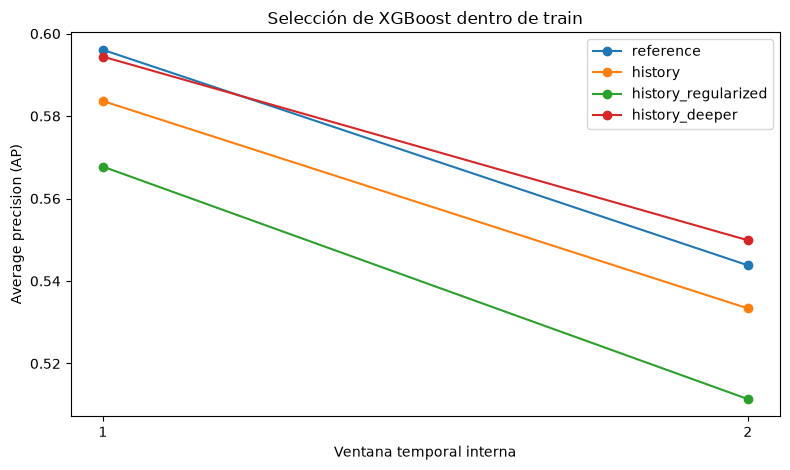

Candidato seleccionado: history_deeper


In [4]:
selection = save_selection(ROOT, train, folds, CANDIDATES, metrics, summary, diagnostics)
fig, ax = plt.subplots(figsize=(8, 4.8))
for name, block in metrics.groupby("candidate", sort=False):
    ax.plot(block.fold, block.average_precision, marker="o", label=name)
ax.set(xlabel="Ventana temporal interna", ylabel="Average precision (AP)", title="Selección de XGBoost dentro de train")
ax.set_xticks(windows.fold)
ax.legend()
fig.tight_layout()
figure_path = ROOT / "results/figures/seleccion_temporal_ap.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Candidato seleccionado:", selection["selected_candidate"]["candidate"])


## 6. Alcance del resultado

En la corrida documentada, history_deeper alcanza AP media 0,5722 frente a 0,5700 de reference: una diferencia pequeña de 0,22 puntos porcentuales. Reference obtiene la mejor AP en el primer fold; history_deeper gana en el segundo. Conservamos history_deeper como candidato por el criterio fijado, sin afirmar superioridad estadística.

Con parámetros iguales, history pierde frente a reference en ambos periodos (AP media 0,5585). Por tanto, no encontramos una mejora automática al añadir el conjunto de atributos. La configuración ganadora combina atributos ampliados y mayor profundidad; sin probar profundidad 8 sobre la base no podemos separar esos efectos.

El diagnóstico muestra historial cero de DeviceInfo en 84,47% y 86,57% de las evaluaciones, incluyendo claves ausentes o nuevas. Esto limita la cobertura de ese proxy; no demuestra que ese porcentaje corresponda a dispositivos físicos nuevos. Las razones y tablas se desarrollan en docs/05_preparacion_y_seleccion_temporal.md.

La salida identifica una configuración candidata para el siguiente ajuste, no un modelo final calibrado. Mantendremos la misma construcción causal de atributos al reajustar con todo train; luego ajustaremos el calibrador usando probabilidades de ese predictor nuevo.

Las cifras de los notebooks 03 y 04 describen otra corrida y otras ventanas; no debemos compararlas directamente con las métricas internas de esta selección. El análisis económico mantiene la matriz original y el corte clasificatorio 0,5. Test permanece reservado.
